In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.metrics import mean_squared_error


# STEP 1: Load MNIST from IDX files 

BASE = "archive" 
TRAIN_IMG = f"{BASE}/train-images.idx3-ubyte"
TRAIN_LBL = f"{BASE}/train-labels.idx1-ubyte"
TEST_IMG  = f"{BASE}/t10k-images.idx3-ubyte"
TEST_LBL  = f"{BASE}/t10k-labels.idx1-ubyte"

def load_images_idx(filename):
    with open(filename, "rb") as f:
        _magic = int.from_bytes(f.read(4), "big")
        n = int.from_bytes(f.read(4), "big")
        rows = int.from_bytes(f.read(4), "big")
        cols = int.from_bytes(f.read(4), "big")
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.reshape(n, rows, cols)

def load_labels_idx(filename):
    with open(filename, "rb") as f:
        _magic = int.from_bytes(f.read(4), "big")
        n = int.from_bytes(f.read(4), "big")
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.reshape(n,)

x_train_full = load_images_idx(TRAIN_IMG)
y_train_full = load_labels_idx(TRAIN_LBL)
x_test_full  = load_images_idx(TEST_IMG)
y_test_full  = load_labels_idx(TEST_LBL)

print("Loaded:")
print("Train:", x_train_full.shape, y_train_full.shape)
print("Test :", x_test_full.shape, y_test_full.shape)

Loaded:
Train: (60000, 28, 28) (60000,)
Test : (10000, 28, 28) (10000,)


In [3]:

# STEP 2: Sample digits {0,1,2} (100 each) for Train & Test

np.random.seed(42)
classes = [0, 1, 2]
n_samples = 100

def sample_n_per_class(x, y, classes, n):
    xs, ys = [], []
    for c in classes:
        idx = np.where(y == c)[0]
        picked = np.random.choice(idx, n, replace=False)
        xs.append(x[picked])
        ys.append(y[picked])
    xs = np.concatenate(xs, axis=0)
    ys = np.concatenate(ys, axis=0)
    perm = np.random.permutation(len(ys))
    return xs[perm], ys[perm]

x_train, y_train = sample_n_per_class(x_train_full, y_train_full, classes, n_samples)
x_test,  y_test  = sample_n_per_class(x_test_full,  y_test_full,  classes, n_samples)

print("\nSampled:")
print("Train:", x_train.shape, y_train.shape, "classes:", {c: int(np.sum(y_train==c)) for c in classes})
print("Test :", x_test.shape,  y_test.shape,  "classes:", {c: int(np.sum(y_test==c)) for c in classes})



Sampled:
Train: (300, 28, 28) (300,) classes: {0: 100, 1: 100, 2: 100}
Test : (300, 28, 28) (300,) classes: {0: 100, 1: 100, 2: 100}


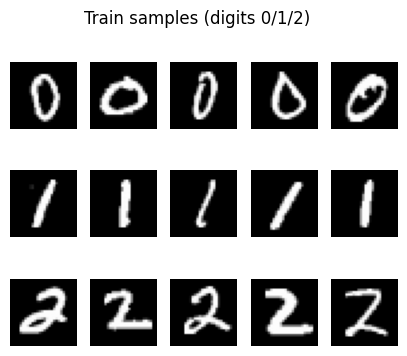

In [4]:

#  Show 5 sample images per class (0/1/2)

samples = {c: [] for c in classes}
for i in range(len(y_train)):
    c = int(y_train[i])
    if len(samples[c]) < 5:
        samples[c].append(x_train[i])

plt.figure(figsize=(5, 4))
for i, c in enumerate(classes):
    for j in range(5):
        plt.subplot(len(classes), 5, i * 5 + j + 1)
        plt.imshow(samples[c][j], cmap="gray")
        plt.axis("off")
plt.suptitle("Train samples (digits 0/1/2)")
plt.show()


In [5]:
# STEP 3: Vectorize + Normalize

x_train_vec = np.array([img.reshape(-1, order='F') for img in x_train], dtype=np.float64) / 255.0
x_test_vec  = np.array([img.reshape(-1, order='F') for img in x_test], dtype=np.float64) / 255.0
print("\nVectorized shapes:")
print("Train:", x_train_vec.shape)
print("Test :", x_test_vec.shape)



Vectorized shapes:
Train: (300, 784)
Test : (300, 784)


In [6]:

# STEP 4: PCA 

class CustomPCA:

    def __init__(self):
        self.avg_vec = None
        self.eig_vals = None
        self.eig_vecs = None
        self.proj_mat = None
        self.num_comp = None
        self.var_share = None
        self.cum_share = None

    def train(self, data):
        data = data.T
        self.avg_vec = np.mean(data, axis=1, keepdims=True)
        centered = data - self.avg_vec
        cov_mat = (centered @ centered.T) / (centered.shape[1] - 1)

        vals, vecs = np.linalg.eigh(cov_mat)

        order = np.argsort(vals)[::-1]
        vals = vals[order]
        vecs = vecs[:, order]

        self.eig_vals = vals
        self.eig_vecs = vecs

        total_var = np.sum(vals)
        self.var_share = vals / total_var
        self.cum_share = np.cumsum(self.var_share)

    def keep_variance(self, thresh):
        self.num_comp = np.searchsorted(self.cum_share, thresh) + 1
        self.proj_mat = self.eig_vecs[:, :self.num_comp]

    def keep_components(self, k):
        self.num_comp = k
        self.proj_mat = self.eig_vecs[:, :k]

    def reduce(self, data):
        data = data.T
        centered = data - self.avg_vec
        low_dim = self.proj_mat.T @ centered
        return low_dim.T

    def reconstruct(self, low_dim):
        low_dim = low_dim.T
        recovered = self.proj_mat @ low_dim + self.avg_vec
        return recovered.T

In [7]:

## PCA 

pca_model = CustomPCA()
pca_model.train(x_train_vec)
pca_model.keep_variance(0.75)

train_red = pca_model.reduce(x_train_vec)
test_red  = pca_model.reduce(x_test_vec)

print("\nPCA with 75% variance")
print("Components kept:", pca_model.num_comp)
print("Variance retained:", pca_model.cum_share[pca_model.num_comp - 1])



PCA with 75% variance
Components kept: 19
Variance retained: 0.7505368321547935



Reconstruction error (MSE): 0.011849397688983816


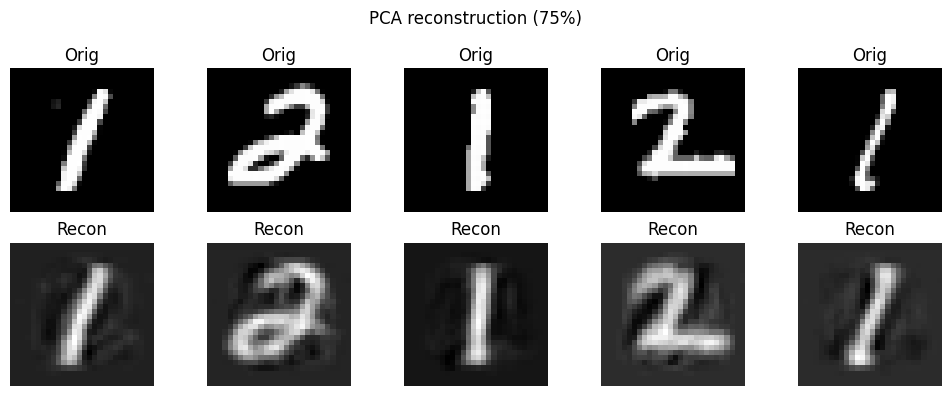

In [8]:

# Reconstruction of 5 samples + MSE

samples = x_train_vec[:5]

low_rep = pca_model.reduce(samples)
restored = pca_model.reconstruct(low_rep)

err = mean_squared_error(samples, restored)

print("\nReconstruction error (MSE):", err)

plt.figure(figsize=(10,4))

for j in range(5):

    plt.subplot(2,5,j+1)
    plt.imshow(samples[j].reshape(28,28,order='F'), cmap='gray')
    plt.title("Orig")
    plt.axis("off")

    plt.subplot(2,5,5+j+1)
    plt.imshow(restored[j].reshape(28,28,order='F'), cmap='gray')
    plt.title("Recon")
    plt.axis("off")

plt.suptitle("PCA reconstruction (75%)")
plt.tight_layout()
plt.show()



In [9]:
# STEP 5: FDA

class MyFDA:
    def __init__(self):
        self.W = None

    def fit(self, X, y):
        class_list = np.unique(y)
        d = X.shape[1]

        overall_mean = np.mean(X, axis=0).reshape(-1, 1)

        SW = np.zeros((d, d))
        SB = np.zeros((d, d))

        for c in class_list:
            Xc = X[y == c]
            mu_c = np.mean(Xc, axis=0).reshape(-1, 1)
            Xc_centered = Xc - mu_c.ravel()
            SW += Xc_centered.T @ Xc_centered
            Nc = Xc.shape[0]
            diff = mu_c - overall_mean
            SB += Nc * (diff @ diff.T)
 
        reg = 1e-6 * np.eye(d)
        A = np.linalg.pinv(SW + reg) @ SB

        eigenvalues, eigenvectors = np.linalg.eig(A)

        idx = np.argsort(np.real(eigenvalues))[::-1]
        eigenvectors = np.real(eigenvectors[:, idx])

        self.W = eigenvectors[:, :len(class_list) - 1]

    def transform(self, X):
        return X @ self.W

fda = MyFDA()
fda.fit(x_train_vec, y_train)

train_fda = fda.transform(x_train_vec)
test_fda  = fda.transform(x_test_vec)

print("\nFDA projection shapes:")
print("Train FDA:", train_fda.shape)
print("Test FDA :", test_fda.shape)


FDA projection shapes:
Train FDA: (300, 2)
Test FDA : (300, 2)


In [10]:
# STEP 6: Classification helpers

def accuracy_score_manual(y_true, y_pred):
    return np.mean(y_true == y_pred)

def print_acc(name, y_true_train, y_pred_train, y_true_test, y_pred_test):
    train_acc = accuracy_score_manual(y_true_train, y_pred_train) * 100
    test_acc = accuracy_score_manual(y_true_test, y_pred_test) * 100
    print(f"\n{name}")
    print(f"Train Accuracy: {train_acc:.2f}%")
    print(f"Test  Accuracy: {test_acc:.2f}%")
    return train_acc, test_acc


class LDA:
    def __init__(self):
        self.cls = None
        self.mu = {}
        self.prior = {}
        self.inv_cov = None
        self.logdet = None

    def fit(self, X, y):
        self.cls = np.unique(y)
        d = X.shape[1]
        n = X.shape[0]

        shared_cov = np.zeros((d, d))

        for c in self.cls:
            Xc = X[y == c]
            self.mu[c] = np.mean(Xc, axis=0)
            self.prior[c] = Xc.shape[0] / n
            diff = Xc - self.mu[c]
            shared_cov += diff.T @ diff

        shared_cov = shared_cov / n
        shared_cov += 1e-6 * np.eye(d)

        self.inv_cov = np.linalg.inv(shared_cov)
        sign, ld = np.linalg.slogdet(shared_cov)
        self.logdet = ld

    def score_one(self, x, c):
        diff = x - self.mu[c]
        return -0.5 * self.logdet - 0.5 * (diff.T @ self.inv_cov @ diff) + np.log(self.prior[c])

    def predict(self, X):
        out = []
        for x in X:
            vals = [self.score_one(x, c) for c in self.cls]
            out.append(self.cls[np.argmax(vals)])
        return np.array(out)


class QDA:
    def __init__(self):
        self.cls = None
        self.mu = {}
        self.prior = {}
        self.inv_cov = {}
        self.logdet = {}

    def fit(self, X, y):
        self.cls = np.unique(y)

        for c in self.cls:
            Xc = X[y == c]
            d = Xc.shape[1]

            self.mu[c] = np.mean(Xc, axis=0)
            self.prior[c] = Xc.shape[0] / X.shape[0]

            diff = Xc - self.mu[c]
            cov = (diff.T @ diff) / Xc.shape[0]
            cov += 1e-6 * np.eye(d)

            self.inv_cov[c] = np.linalg.inv(cov)
            sign, ld = np.linalg.slogdet(cov)
            self.logdet[c] = ld

    def score_one(self, x, c):
        diff = x - self.mu[c]
        return -0.5 * self.logdet[c] - 0.5 * (diff.T @ self.inv_cov[c] @ diff) + np.log(self.prior[c])

    def predict(self, X):
        out = []
        for x in X:
            vals = [self.score_one(x, c) for c in self.cls]
            out.append(self.cls[np.argmax(vals)])
        return np.array(out)


In [11]:

# STEP 7: FDA + LDA

lda_fda = LDA()
lda_fda.fit(train_fda, y_train)

y_train_pred_fda_lda = lda_fda.predict(train_fda)
y_test_pred_fda_lda = lda_fda.predict(test_fda)

acc_train_fda_lda, acc_test_fda_lda = print_acc(
    "FDA + LDA",
    y_train, y_train_pred_fda_lda,
    y_test, y_test_pred_fda_lda
)


FDA + LDA
Train Accuracy: 100.00%
Test  Accuracy: 85.33%


In [12]:
# STEP 8: FDA + QDA

qda_fda = QDA()
qda_fda.fit(train_fda, y_train)

y_train_pred_fda_qda = qda_fda.predict(train_fda)
y_test_pred_fda_qda = qda_fda.predict(test_fda)

acc_train_fda_qda, acc_test_fda_qda = print_acc(
    "FDA + QDA",
    y_train, y_train_pred_fda_qda,
    y_test, y_test_pred_fda_qda
)


FDA + QDA
Train Accuracy: 100.00%
Test  Accuracy: 85.33%


In [13]:
# STEP 9: PCA + LDA

lda_pca75 = LDA()
lda_pca75.fit(train_red, y_train)

y_train_pred_pca75 = lda_pca75.predict(train_red)
y_test_pred_pca75 = lda_pca75.predict(test_red)

acc_train_pca75, acc_test_pca75 = print_acc(
    "PCA(75%) + LDA",
    y_train, y_train_pred_pca75,
    y_test, y_test_pred_pca75
)



PCA(75%) + LDA
Train Accuracy: 97.00%
Test  Accuracy: 94.67%


In [14]:

# STEP 10: PCA + LDA

pca90 = CustomPCA()
pca90.train(x_train_vec)
pca90.keep_variance(0.90)

train_pca90 = pca90.reduce(x_train_vec)
test_pca90  = pca90.reduce(x_test_vec)

print("\nPCA (90% variance)")
print("Number of components retained:", pca90.num_comp)
print("Cumulative variance retained:", pca90.cum_share[pca90.num_comp - 1])

lda_pca90 = LDA()
lda_pca90.fit(train_pca90, y_train)

y_train_pred_pca90 = lda_pca90.predict(train_pca90)
y_test_pred_pca90 = lda_pca90.predict(test_pca90)

acc_train_pca90, acc_test_pca90 = print_acc(
    "PCA(90%) + LDA",
    y_train, y_train_pred_pca90,
    y_test, y_test_pred_pca90
)


PCA (90% variance)
Number of components retained: 51
Cumulative variance retained: 0.9016730097510987

PCA(90%) + LDA
Train Accuracy: 99.67%
Test  Accuracy: 96.00%


In [15]:

# STEP 11: PCA + LDA

pca2 = CustomPCA()
pca2.train(x_train_vec)
pca2.keep_components(2)

train_pca2 = pca2.reduce(x_train_vec)
test_pca2  = pca2.reduce(x_test_vec)

lda_pca2 = LDA()
lda_pca2.fit(train_pca2, y_train)

y_train_pred_pca2 = lda_pca2.predict(train_pca2)
y_test_pred_pca2 = lda_pca2.predict(test_pca2)

acc_train_pca2, acc_test_pca2 = print_acc(
    "PCA(first 2 PCs) + LDA",
    y_train, y_train_pred_pca2,
    y_test, y_test_pred_pca2
)



PCA(first 2 PCs) + LDA
Train Accuracy: 92.67%
Test  Accuracy: 91.00%


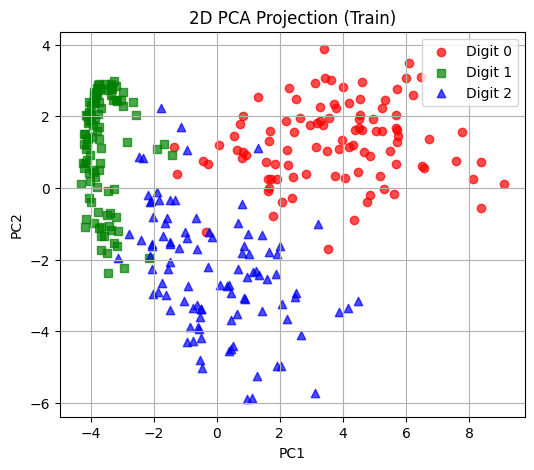

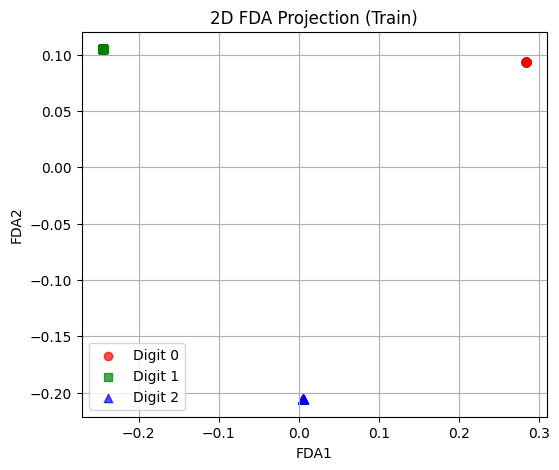

In [16]:
# STEP 12: 2D Visualization for PCA and FDA

markers = {0: 'o', 1: 's', 2: '^'}
colors = {0: 'red', 1: 'green', 2: 'blue'}

# PCA 2D plot
plt.figure(figsize=(6, 5))
for c in classes:
    idx = np.where(y_train == c)[0]
    plt.scatter(
        train_pca2[idx, 0],
        train_pca2[idx, 1],
        c=colors[c],
        marker=markers[c],
        label=f"Digit {c}",
        alpha=0.7
    )
plt.title("2D PCA Projection (Train)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True)
plt.show()

# FDA 2D plot
plt.figure(figsize=(6, 5))
for c in classes:
    idx = np.where(y_train == c)[0]
    plt.scatter(
        train_fda[idx, 0],
        train_fda[idx, 1],
        c=colors[c],
        marker=markers[c],
        label=f"Digit {c}",
        alpha=0.7
    )
plt.title("2D FDA Projection (Train)")
plt.xlabel("FDA1")
plt.ylabel("FDA2")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# STEP 13: Final summary table
print("\n" + "=" * 60)
print("FINAL ACCURACY SUMMARY")
print("=" * 60)
print(f"{'Method':25s} {'Train Acc (%)':15s} {'Test Acc (%)':15s}")
print("-" * 60)
print(f"{'FDA + LDA':25s} {acc_train_fda_lda:15.2f} {acc_test_fda_lda:15.2f}")
print(f"{'FDA + QDA':25s} {acc_train_fda_qda:15.2f} {acc_test_fda_qda:15.2f}")
print(f"{'PCA(75%) + LDA':25s} {acc_train_pca75:15.2f} {acc_test_pca75:15.2f}")
print(f"{'PCA(90%) + LDA':25s} {acc_train_pca90:15.2f} {acc_test_pca90:15.2f}")
print(f"{'PCA(2 PCs) + LDA':25s} {acc_train_pca2:15.2f} {acc_test_pca2:15.2f}")
print("=" * 60)


FINAL ACCURACY SUMMARY
Method                    Train Acc (%)   Test Acc (%)   
------------------------------------------------------------
FDA + LDA                          100.00           85.33
FDA + QDA                          100.00           85.33
PCA(75%) + LDA                      97.00           94.67
PCA(90%) + LDA                      99.67           96.00
PCA(2 PCs) + LDA                    92.67           91.00
